# **IMPORTING LIBRARIES**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')


In [2]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import SMOTE

# **LOADING DATASET**

In [4]:
df=pd.read_csv(r"F:\TechJobs-Tasks\ML Project\loan_data.csv")

# **DATASET OVERVIEW**

In [5]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [6]:
df.shape

(9578, 14)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.2 MB


In [8]:
df.columns

Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='str')

In [9]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


# **CHECKING FOR NULL VALUES**

In [10]:
null_cnt=df.isnull().sum()
null_cnt

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

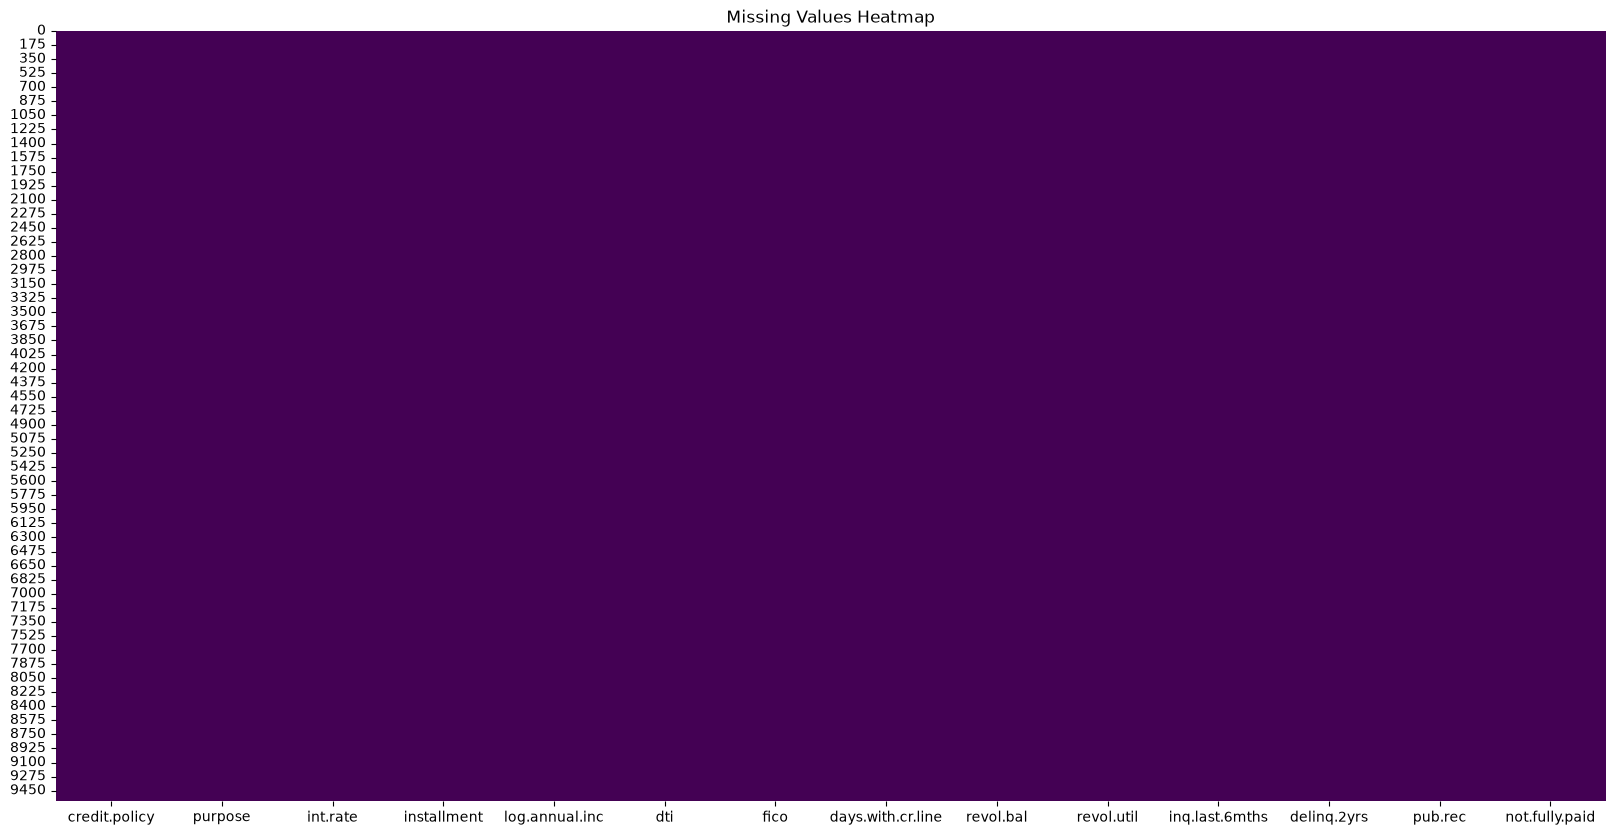

In [11]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

## **Observation**

1. The missing values heatmap is completely uniform, indicating that there are no missing (null) values present in any of the dataset's columns.

2. Since all features contain complete data, no missing value imputation or preprocessing for null values is required before performing further analysis or model building.

# **CHECKING FOR DUPLICATE VALUES**

In [12]:
dupl_cnt=df.duplicated().sum()
dupl_cnt

np.int64(0)

In [13]:
(df.select_dtypes(include='number')<0).sum()

credit.policy        0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

# **CHECKING FOR UNIQUE VALUES**

In [14]:
uniq_cnt=df.nunique()
uniq_cnt

credit.policy           2
purpose                 7
int.rate              249
installment          4788
log.annual.inc       1987
dti                  2529
fico                   44
days.with.cr.line    2687
revol.bal            7869
revol.util           1035
inq.last.6mths         28
delinq.2yrs            11
pub.rec                 6
not.fully.paid          2
dtype: int64

# **CHECKING FOR NEGATIVE VALUES**

In [15]:
(df.select_dtypes(include='number')<0).sum()

credit.policy        0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

# **Observation**

There are no negative values

# **EXPLORATORY DATA ANALYSIS (EDA)**

In [16]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [17]:
df.tail()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1
9577,0,debt_consolidation,0.1392,853.43,11.264464,16.28,732,4740.000000,37879,57.0,6,0,0,1


## UNIVARIATE ANALYSIS

In [18]:
df["credit.policy"].value_counts()   #It displays the count of each target class

credit.policy
1    7710
0    1868
Name: count, dtype: int64

## DESCRIPTION

1-> Customer meets bank credit policy

0-> Customer does not meet the credit policy

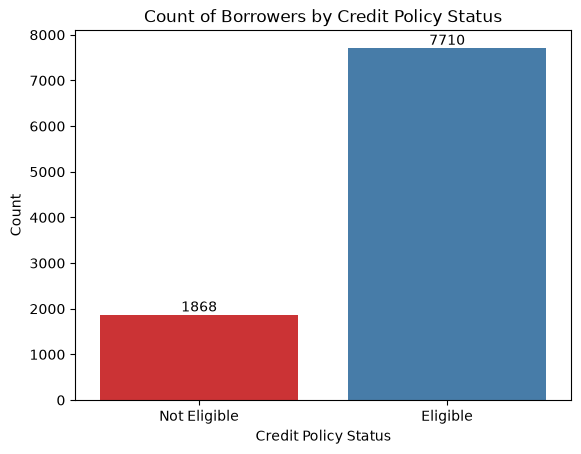

In [19]:
ax = sns.countplot(x="credit.policy", data=df, palette="Set1")

plt.xticks([0, 1], ["Not Eligible", "Eligible"])
plt.xlabel("Credit Policy Status")
plt.ylabel("Count")

for containers in ax.containers:
    ax.bar_label(containers)

plt.title("Count of Borrowers by Credit Policy Status")
plt.show()

## **OBSERVATION:**



*  Most borrowers satisfy the bank's credit policy (Met).
* Only a small number of borrowers do not satisfy the bank's credit policy (Not Met).



In [20]:
df["credit.policy"].value_counts(normalize=True)*100   #It displays the percentage of each target class

credit.policy
1    80.496972
0    19.503028
Name: proportion, dtype: float64

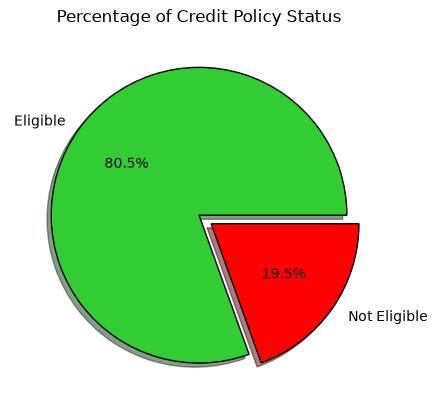

In [21]:
plt.pie(df["credit.policy"].value_counts(),autopct="%1.1f%%",shadow=True,labels=[" Eligible"," Not Eligible"],colors=['limegreen','red'],explode=[0,0.1],wedgeprops={'edgecolor':'black'})
plt.title("Percentage of Credit Policy Status")
plt.show()


*   Approximately 80% of borrowers satisfy the bank's credit policy (Eligible).
*   Approximately 20% of borrowers do not satisfy the bank's credit policy (Not Eligible).


In [22]:
df['purpose'].value_counts()

purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64

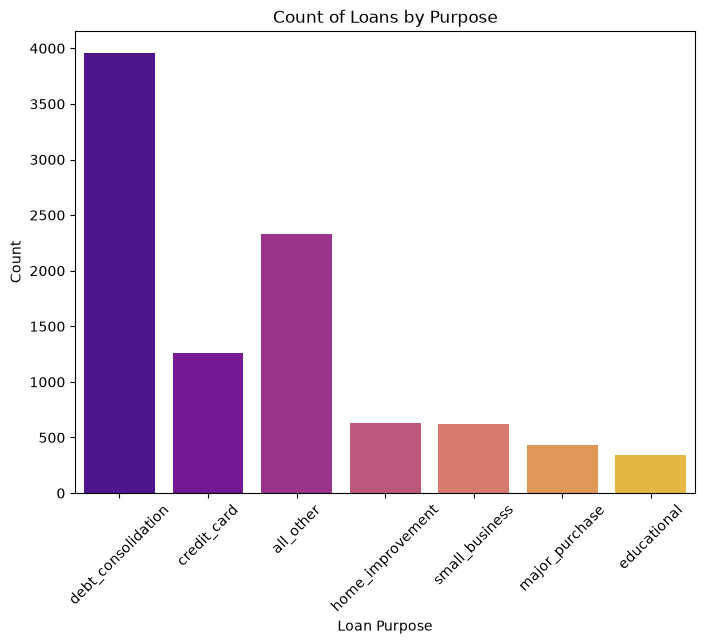

In [23]:
plt.figure(figsize=(8,6))
sns.countplot(x='purpose',data=df,palette='plasma')
plt.xticks(rotation=45)
plt.xlabel('Loan Purpose')
plt.ylabel('Count')
plt.title('Count of Loans by Purpose')
plt.show()

## **OBSERVATION**


*   debt_consolidation has highest count
*   educational loans have least count



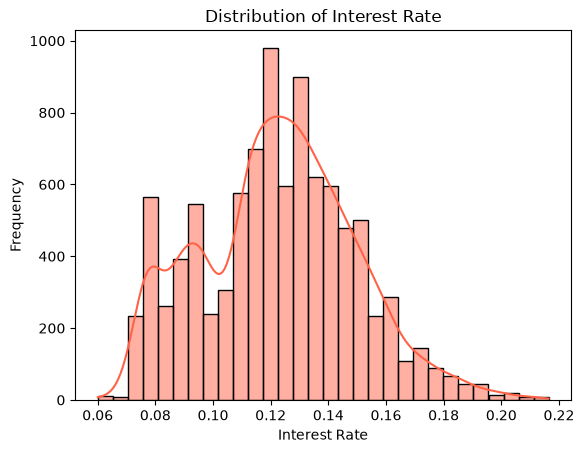

In [24]:
sns.histplot(df["int.rate"],kde=True,bins=30,color="tomato")
plt.title("Distribution of Interest Rate")
plt.xlabel("Interest Rate")
plt.ylabel("Frequency")
plt.show()

## **OBSERVATION**



*   The distribution of interest rates is concentrated around 12–13%, indicating that most borrowers receive moderate interest rates.
* The distribution is slightly positively skewed, with relatively few borrowers receiving very high interest rates above 16%.
* This suggests that high-risk loans are less common in the dataset.




In [25]:
df['pub.rec'].value_counts()

pub.rec
0    9019
1     533
2      19
3       5
4       1
5       1
Name: count, dtype: int64

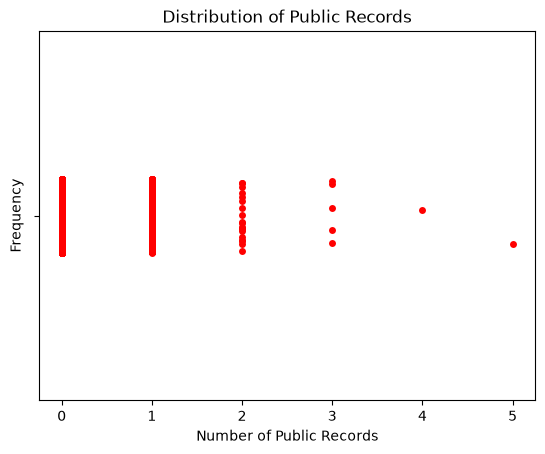

In [26]:
sns.stripplot(x=df['pub.rec'],color='red',jitter=True)
plt.title("Distribution of Public Records")
plt.xlabel("Number of Public Records")
plt.ylabel("Frequency")
plt.show()

## **OBSERVATION**

Most borrowers have zero to one public record(s), very few have more than one public records.

In [27]:
df['inq.last.6mths'].value_counts()


inq.last.6mths
0     3637
1     2462
2     1384
3      864
4      475
5      278
6      165
7      100
8       72
9       47
10      23
12      15
11      15
15       9
14       6
13       6
18       4
16       3
19       2
24       2
17       2
33       1
20       1
27       1
25       1
28       1
31       1
32       1
Name: count, dtype: int64

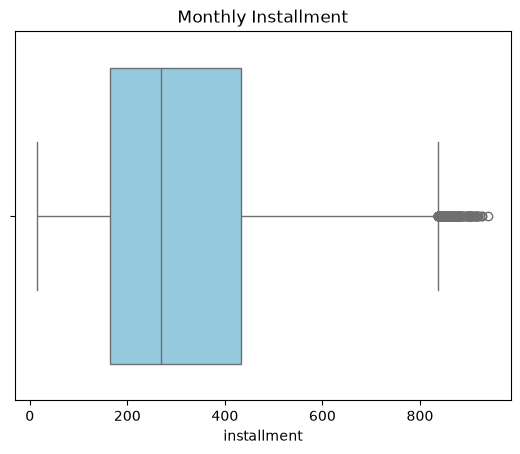

In [28]:
sns.boxplot(x=df["installment"],color="skyblue")
plt.title("Monthly Installment")
plt.show()

## **OBSERVATION**



* The Q1 value is less than 200 and Q3 value is greater than 400.
* The median installment values lie between 200-400.
* Several high installment values are outliers meaning that few people pay high monthly installments than the rest.



## BIVARIATE ANALYSIS

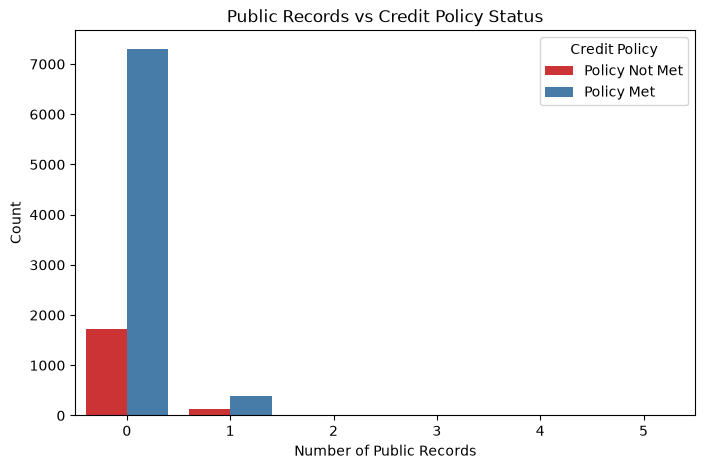

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(x="pub.rec",hue="credit.policy",data=df,palette="Set1")
plt.xlabel("Number of Public Records")
plt.ylabel("Count")
plt.title("Public Records vs Credit Policy Status")
plt.legend(title="Credit Policy",labels=["Policy Not Met", "Policy Met"])
plt.show()

## **OBSERVATION**



* Most borrowers have 0 public records, and the majority of them meet the credit policy.

* As the number of public records increases, the number of borrowers decreases across both credit policy groups.




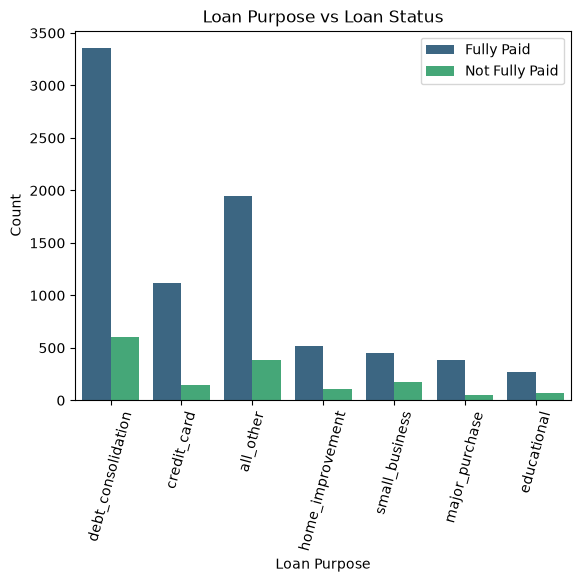

In [30]:
sns.countplot(x="purpose",hue="not.fully.paid",data=df,palette="viridis")
plt.xticks(rotation=75)
plt.title("Loan Purpose vs Loan Status")
plt.xlabel("Loan Purpose")
plt.ylabel("Count")
plt.legend(["Fully Paid","Not Fully Paid"])
plt.show()

## **OBSERVATION**



* debt_consolidation loans are the most common.
* small_business loans generally show a higher proportion of defaults.
* educational** loans have relatively fewer observations.

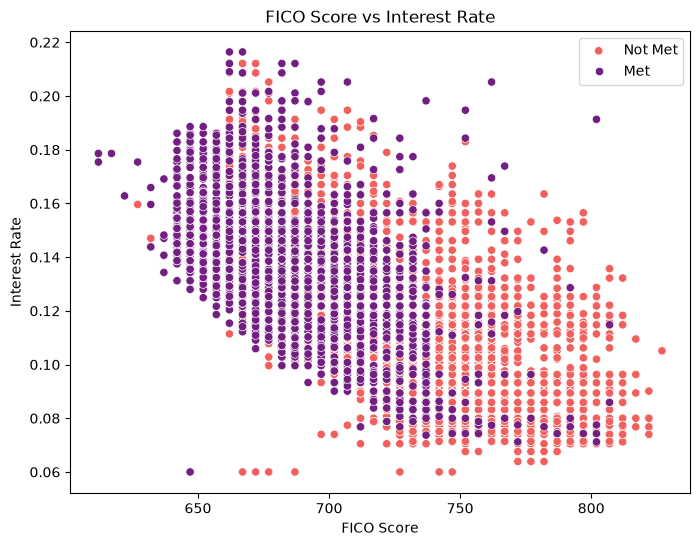

In [31]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="fico",y="int.rate",hue="credit.policy",data=df,palette="magma")
plt.xlabel("FICO Score")
plt.ylabel("Interest Rate")
plt.legend(["Not Met","Met"])
plt.title("FICO Score vs Interest Rate")
plt.show()

## **OBSERVATION**


* Borrowers with higher FICO scores generally receive lower interest rates.
* Borrowers with lower FICO scores are more likely to have higher interest rates and greater credit risk.



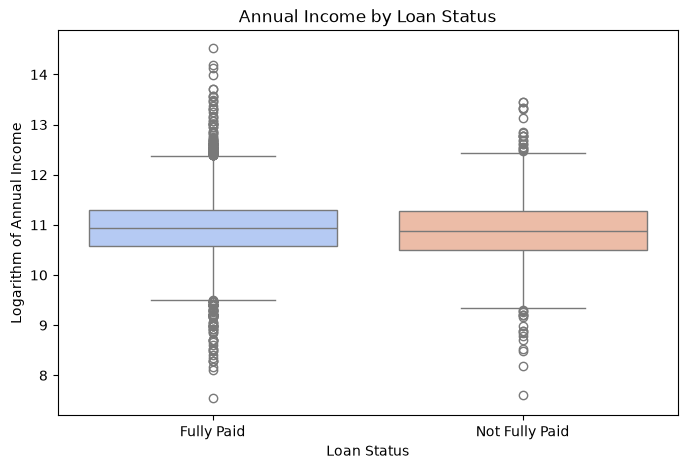

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x="not.fully.paid",y="log.annual.inc",data=df,palette="coolwarm")
plt.xticks([0,1],["Fully Paid","Not Fully Paid"])
plt.xlabel("Loan Status")
plt.ylabel("Logarithm of Annual Income")
plt.title("Annual Income by Loan Status")
plt.show()

## **OBSERVATION**



*   The median annual income is similar for both borrower groups.
* Both groups contain a few high and low income outliers.



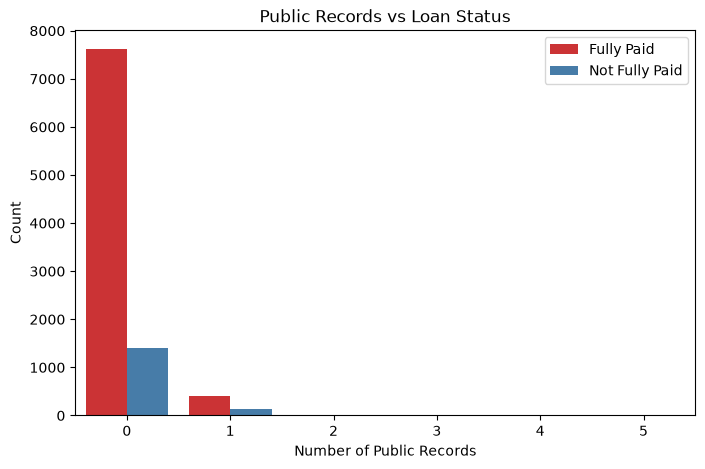

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(x="pub.rec",hue="not.fully.paid",data=df,palette="Set1")
plt.xlabel("Number of Public Records")
plt.ylabel("Count")
plt.legend(["Fully Paid","Not Fully Paid"])
plt.title("Public Records vs Loan Status")
plt.show()

## **OBSERVATION**



*   Most borrowers have zero public records.
* Borrowers with public records are fewer and have a higher chance of loan default.



In [34]:
df.groupby("credit.policy")["int.rate"].mean()

credit.policy
0    0.138680
1    0.118754
Name: int.rate, dtype: float64

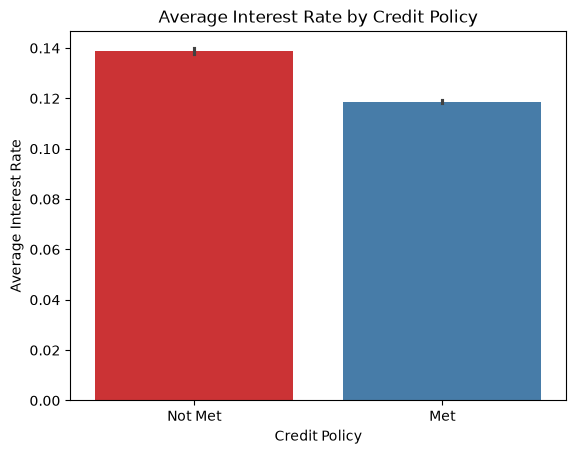

In [35]:
sns.barplot(x="credit.policy",y="int.rate",data=df,palette="Set1")
plt.xticks([0,1],["Not Met","Met"])
plt.xlabel("Credit Policy")
plt.ylabel("Average Interest Rate")
plt.title("Average Interest Rate by Credit Policy")
plt.show()

## **OBSERVATION**



*   Borrowers who did not meet the credit policy generally have higher average interest rates.



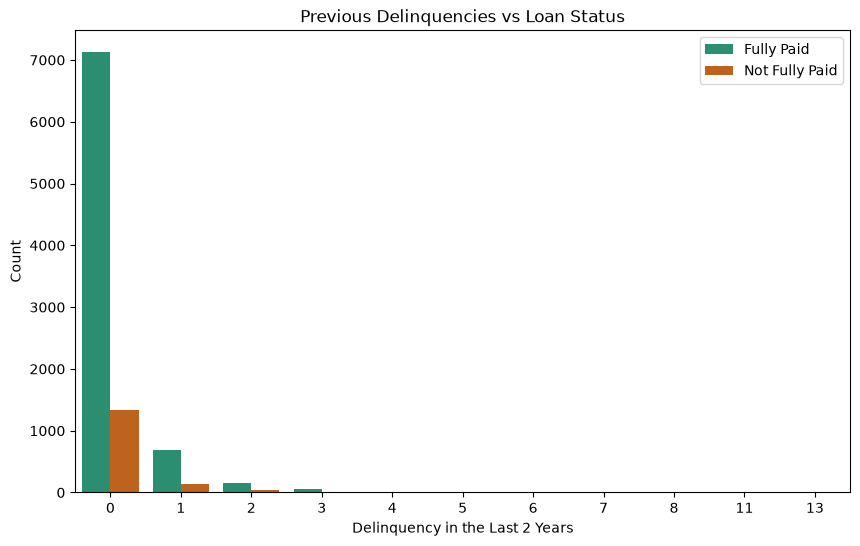

In [36]:
plt.figure(figsize=(10,6))
sns.countplot(x="delinq.2yrs",hue="not.fully.paid",data=df,palette="Dark2")
plt.xlabel("Delinquency in the Last 2 Years")
plt.ylabel("Count")
plt.legend(["Fully Paid","Not Fully Paid"])
plt.title("Previous Delinquencies vs Loan Status")
plt.show()

## **OBSERVATION**

Most people not having any previous delinquencies have paid the loan. 

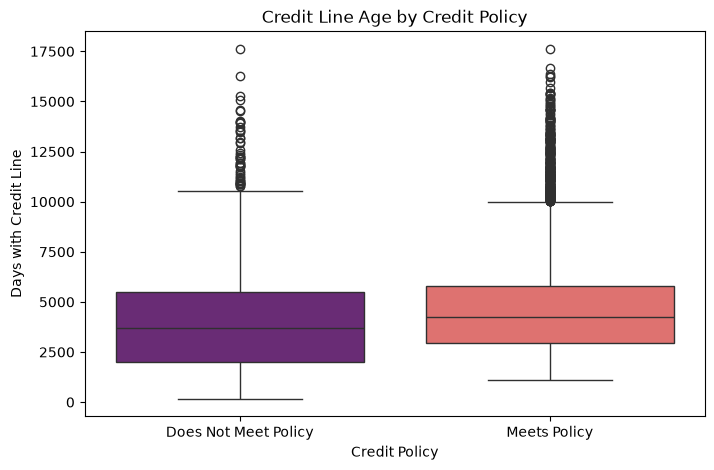

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="credit.policy",
    y="days.with.cr.line",
    data=df,
    palette="magma"
)
plt.xlabel("Credit Policy")
plt.ylabel("Days with Credit Line")
plt.xticks([0,1], ["Does Not Meet Policy", "Meets Policy"])
plt.title("Credit Line Age by Credit Policy")

plt.show()

## **OBSERVATION**



*   Borrowers who meet the credit policy generally have a slightly older credit history.
.
*   Both groups show many outliers, indicating some borrowers have very long credit histories.



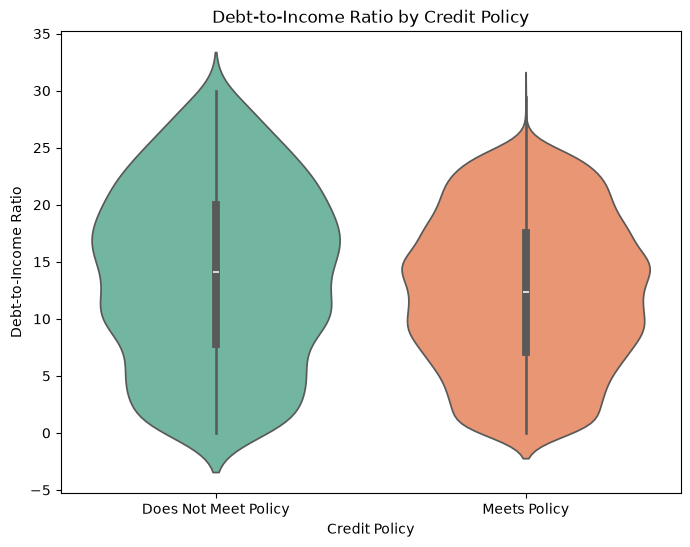

In [38]:
plt.figure(figsize=(8,6))

sns.violinplot(
    x='credit.policy',
    y='dti',
    data=df,
    palette="Set2"
)

plt.xlabel("Credit Policy")
plt.ylabel("Debt-to-Income Ratio")
plt.xticks([0,1], ["Does Not Meet Policy", "Meets Policy"])
plt.title("Debt-to-Income Ratio by Credit Policy")

plt.show()

## **OBSERVATION**



*   Borrowers who meet the credit policy tend to have a slightly lower debt-to-income ratio.
* The debt-to-income ratio varies widely in both credit policy groups.




In [39]:
df['credit.policy'].value_counts()

credit.policy
1    7710
0    1868
Name: count, dtype: int64

In [40]:
df1=df.copy()

In [41]:
all_col = df1.select_dtypes(include=["number","object"])

In [42]:
all_col.shape

(9578, 14)

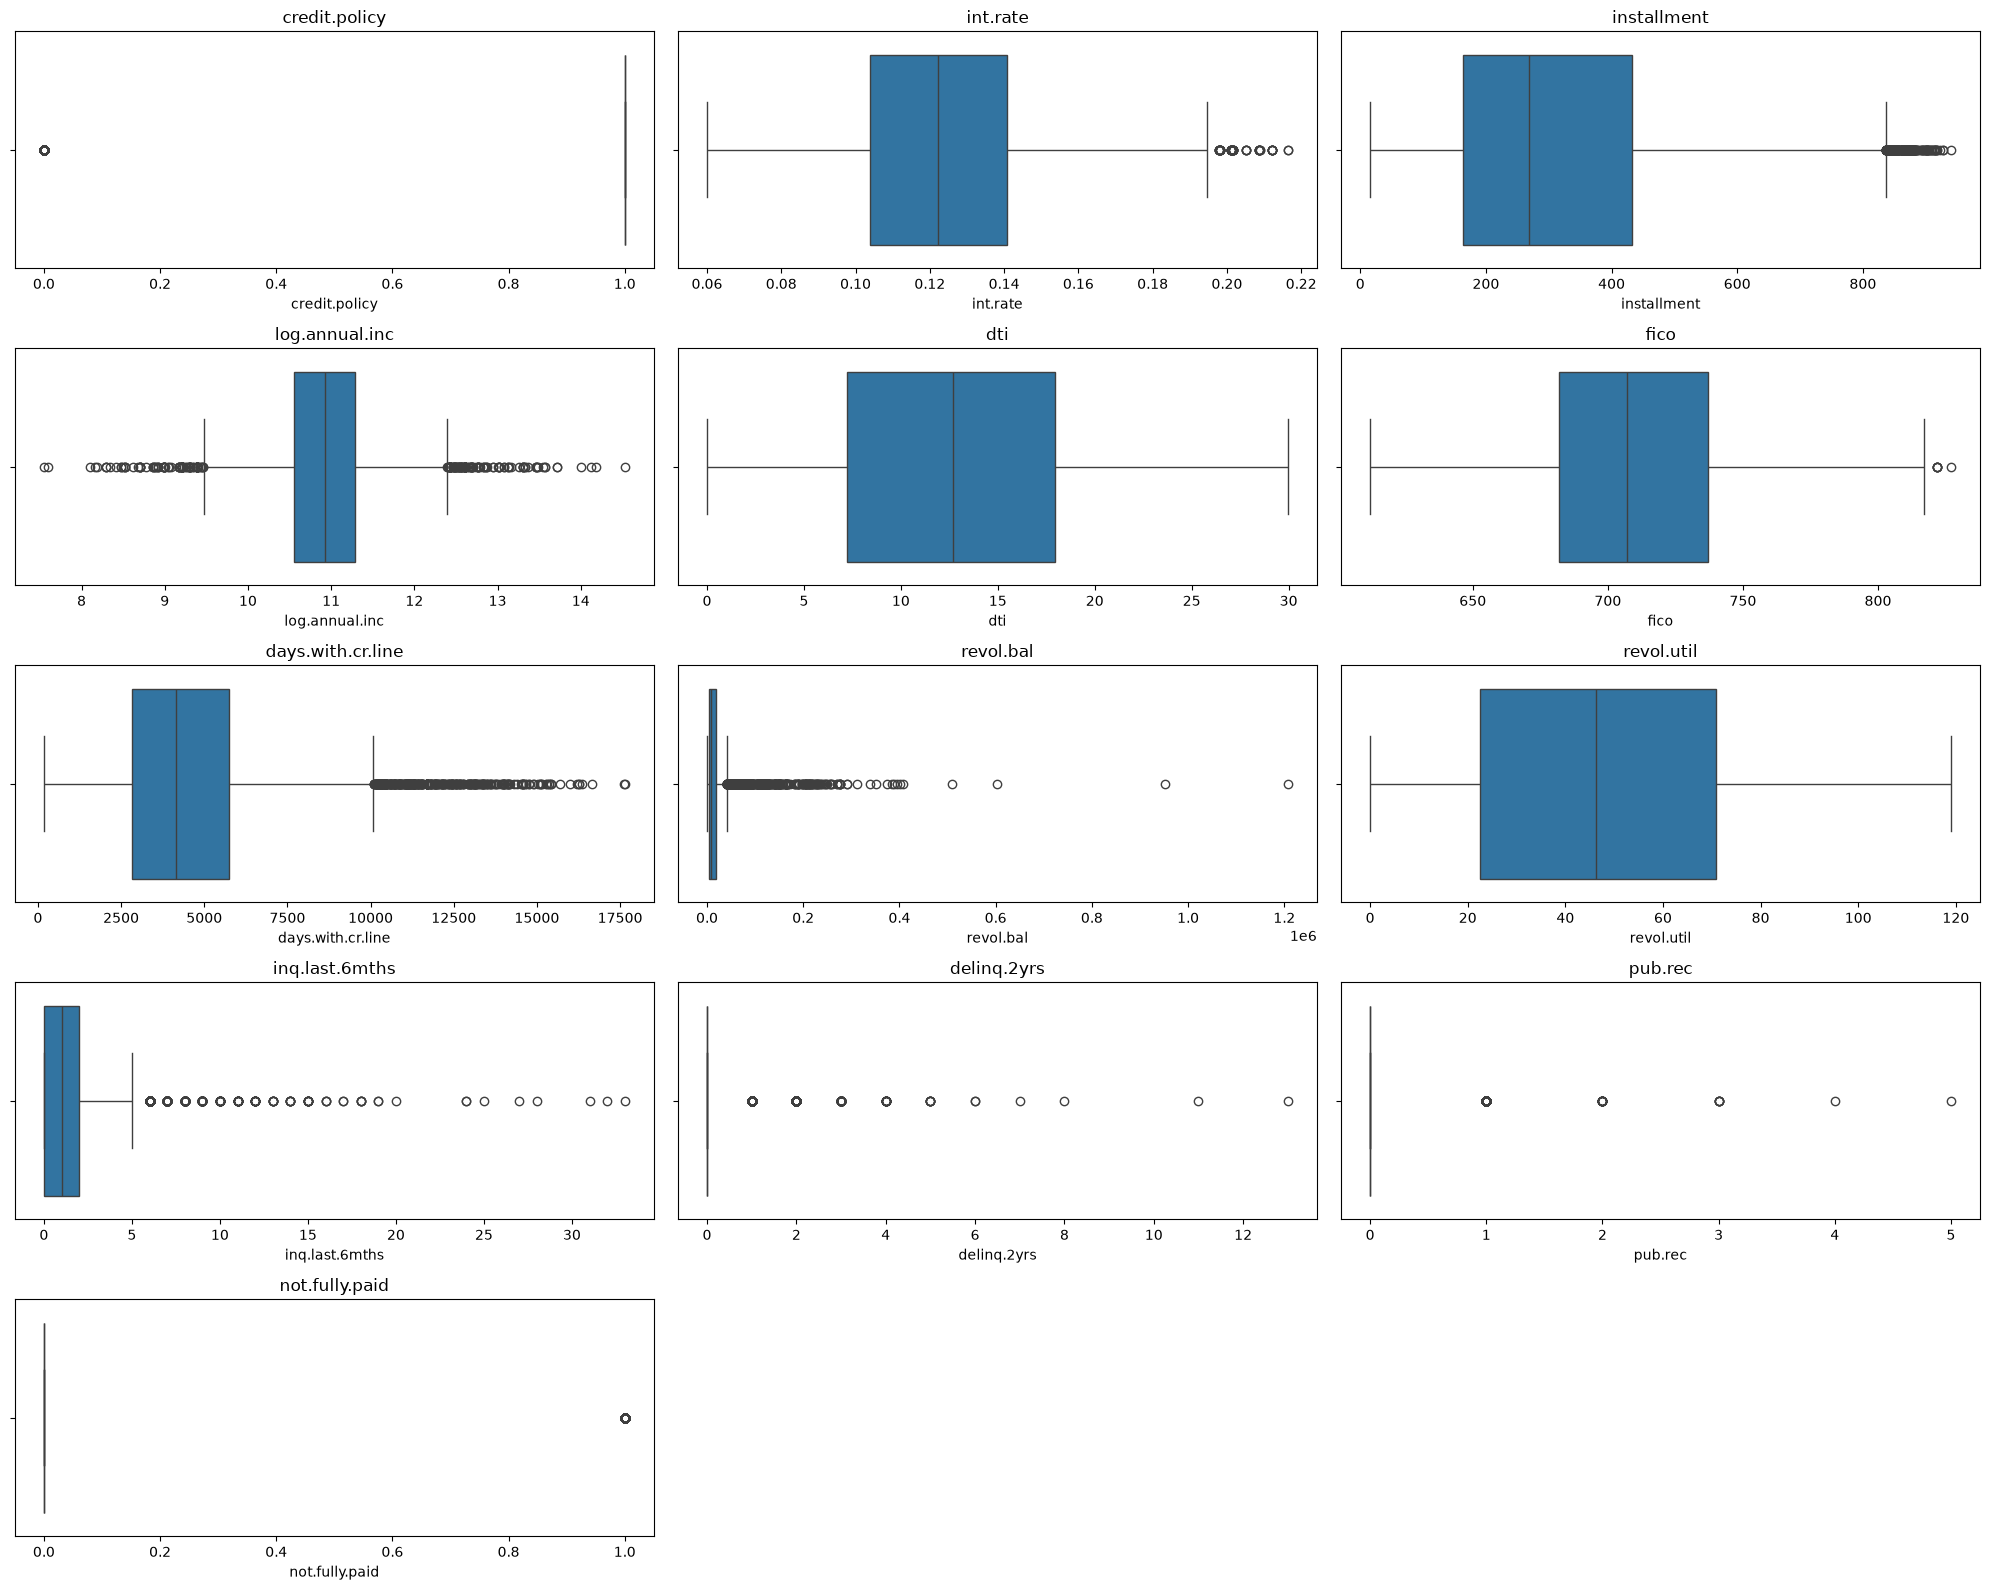

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = all_col.select_dtypes(include=['number']).columns

plt.figure(figsize=(20,16))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


## **OBSERVATION**



*   The numerical features show wide variation, reflecting differences in borrower and loan characteristics.

*   Most variables have a broad range of values, indicating diverse loan amounts, credit history, and financial profiles.



In [44]:
num_col=["int.rate","installment","log.annual.inc","dti","fico","days.with.cr.line","revol.bal","revol.util","inq.last.6mths","delinq.2yrs"]

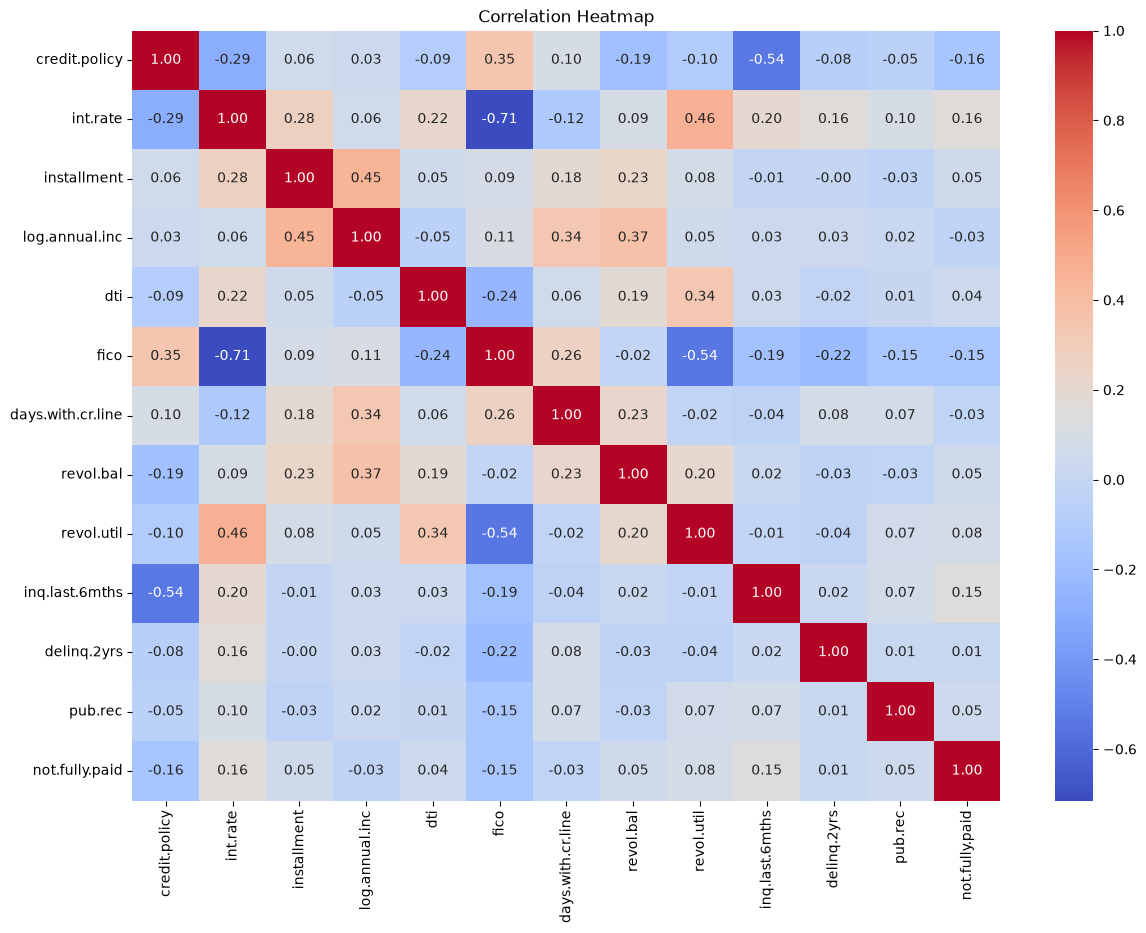

In [45]:
num_cols = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(14,10))
sns.heatmap(num_cols.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## **OBSERVATION**





*  Most features have weak to moderate correlations, indicating they provide distinct information.

*   A few feature pairs show strong positive correlations, suggesting related financial characteristics.





## **LABEL ENCODING**

In [46]:
from sklearn.preprocessing import LabelEncoder
le={}
LabelEncoder=LabelEncoder()
for col in df1.select_dtypes(include=["object"]).columns:
  df1[col]=LabelEncoder.fit_transform(df1[col])
  le[col]=LabelEncoder

## **TRAIN TEST SPLIT**

In [47]:
from sklearn.model_selection import train_test_split
y=df["credit.policy"]
X=df.drop(["credit.policy","not.fully.paid"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (6704, 12)
Testing data shape: (2874, 12)




*   Stored all predictor variables in X
*  We store the target variable (credit,policy) in y



Droping the not.fully.paid column because it can leak the data

In [48]:
df1.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,2,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,2,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,2,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


# **SMOTE**

In [49]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()
scaler = StandardScaler()

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

if 'purpose' in X_train_enc.columns:
    X_train_enc['purpose'] = le['purpose'].transform(X_train_enc['purpose'])
    X_test_enc['purpose'] = le['purpose'].transform(X_test_enc['purpose'])

X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Original Training Data:\n{y_train.value_counts()}")
print(f"Resampled Training Data:\n{y_train_resampled.value_counts()}")
X_test_scaled = scaler.transform(X_test_enc)


Original Training Data:
credit.policy
1    5397
0    1307
Name: count, dtype: int64
Resampled Training Data:
credit.policy
1    5397
0    5397
Name: count, dtype: int64


# **LOGISTIC REGRESSION**

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression(random_state=42, max_iter=1000)


In [51]:
log_reg.fit(X_train_resampled, y_train_resampled)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [52]:
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [53]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(f'Train Accuracy: {log_reg.score(X_train_resampled, y_train_resampled)}')
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8562978427279053
Train Accuracy: 0.8512136372058551
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.85      0.70       561
           1       0.96      0.86      0.91      2313

    accuracy                           0.86      2874
   macro avg       0.78      0.85      0.80      2874
weighted avg       0.89      0.86      0.87      2874

Confusion Matrix:
 [[ 478   83]
 [ 330 1983]]


In [54]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.9344


**HYPERTUNING**

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [56]:
log_param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
log_grid = GridSearchCV(log_reg, log_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
log_grid.fit(X_train_resampled, y_train_resampled)

best_log_reg = log_grid.best_estimator_

y_train_pred_log = best_log_reg.predict(X_train_resampled)
y_test_pred_log = best_log_reg.predict(X_test_scaled)
y_train_pred_proba_log = best_log_reg.predict_proba(X_train_resampled)[:, 1]

print(f"Best Parameters: {log_grid.best_params_}")
print(f"Logistic Regression Training Accuracy: {accuracy_score(y_train_resampled, y_train_pred_log):.4f}")
print(f"Logistic Regression Testing Accuracy: {accuracy_score(y_test, y_test_pred_log):.4f}")
print("\nClassification Report (Test Data):\n", classification_report(y_test, y_test_pred_log))

Best Parameters: {'C': 0.1}
Logistic Regression Training Accuracy: 0.8510
Logistic Regression Testing Accuracy: 0.8570

Classification Report (Test Data):
               precision    recall  f1-score   support

           0       0.59      0.85      0.70       561
           1       0.96      0.86      0.91      2313

    accuracy                           0.86      2874
   macro avg       0.78      0.86      0.80      2874
weighted avg       0.89      0.86      0.87      2874



In [57]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.9344


# **DECISION TREE**

In [58]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(random_state=42)


In [59]:
dt_clf.fit(X_train_resampled, y_train_resampled)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [60]:
y_pred = dt_clf.predict(X_test_scaled)
y_pred_proba = dt_clf.predict_proba(X_test_scaled)[:, 1]

In [61]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print("ROC AUC:", roc_auc)

Accuracy: 0.9826026443980515
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       561
           1       0.99      0.98      0.99      2313

    accuracy                           0.98      2874
   macro avg       0.97      0.98      0.97      2874
weighted avg       0.98      0.98      0.98      2874

Confusion Matrix:
 [[ 546   15]
 [  35 2278]]
ROC AUC: 0.9790650843523355


**HYPERTUNING**

In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [63]:
dt_param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

dt_grid = GridSearchCV(dt_clf, dt_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train_resampled, y_train_resampled)


best_dt = dt_grid.best_estimator_
y_train_pred_dt = best_dt.predict(X_train_resampled)
y_test_pred_dt = best_dt.predict(X_test_scaled)

print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Decision Tree Training Accuracy: {accuracy_score(y_train_resampled, y_train_pred_dt):.4f}")
print(f"Decision Tree Testing Accuracy: {accuracy_score(y_test, y_test_pred_dt):.4f}")
print("\nClassification Report (Test Data):\n", classification_report(y_test, y_test_pred_dt))

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Decision Tree Training Accuracy: 0.9860
Decision Tree Testing Accuracy: 0.9882

Classification Report (Test Data):
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       561
           1       0.99      1.00      0.99      2313

    accuracy                           0.99      2874
   macro avg       0.99      0.98      0.98      2874
weighted avg       0.99      0.99      0.99      2874



In [64]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.9791


# **RANDOM FOREST**

In [65]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(random_state=42)


In [66]:
rf_clf.fit(X_train_resampled, y_train_resampled)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [67]:
y_pred = rf_clf.predict(X_test_scaled)
y_pred_proba = rf_clf.predict_proba(X_test_scaled)[:, 1]

In [68]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.9860821155184412
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96       561
           1       0.99      1.00      0.99      2313

    accuracy                           0.99      2874
   macro avg       0.98      0.97      0.98      2874
weighted avg       0.99      0.99      0.99      2874

Confusion Matrix:
 [[ 531   30]
 [  10 2303]]
ROC AUC: 0.9973


**HYPERTUNING**

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV




In [70]:
rf_clf_rs = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_param_dist = {
    "max_depth":[5,8,10,12,15],
    "min_samples_split":[5,10,15,20,30],
    "min_samples_leaf":[2,4,6,8,10],
    "max_features":["sqrt","log2",0.3,0.5],
    "bootstrap":[True],
    "max_samples":[0.6,0.7,0.8,0.9],
    "class_weight":["balanced","balanced_subsample"]
}


In [71]:
rf_random_search = RandomizedSearchCV(
    estimator=rf_clf_rs,
    param_distributions=rf_param_dist,
    n_iter=15,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)


In [72]:
rf_random_search.fit(X_train_resampled, y_train_resampled)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True], 'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': [5, 8, ...], 'max_features': ['sqrt', 'log2', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` inst

In [73]:
best_rf_rs = rf_random_search.best_estimator_


In [74]:
print(best_rf_rs.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 12, 'max_features': 0.3, 'max_leaf_nodes': None, 'max_samples': 0.9, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 15, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [75]:
rf_random_search.best_params_


{'min_samples_split': 15,
 'min_samples_leaf': 4,
 'max_samples': 0.9,
 'max_features': 0.3,
 'max_depth': 12,
 'class_weight': 'balanced',
 'bootstrap': True}

In [76]:
rf_random_search.best_score_

np.float64(0.9977836491831513)

In [77]:
y_train_pred_fast = best_rf_rs.predict(X_train_resampled)
y_test_pred_fast = best_rf_rs.predict(X_test_scaled)
y_train_prob_fast = best_rf_rs.predict_proba(X_train_resampled)[:, 1]
y_test_prob_fast = best_rf_rs.predict_proba(X_test_scaled)[:, 1]



In [78]:
from sklearn.metrics import roc_auc_score

print(f"\nBest Hyperparameters: {rf_random_search.best_params_}")
print(f"Optimized RF Training Accuracy: {accuracy_score(y_train_resampled, y_train_pred_fast):.4f}")
print(f"Optimized RF Testing Accuracy:  {accuracy_score(y_test, y_test_pred_fast):.4f}")
print(f"Optimized RF Training ROC AUC:  {roc_auc_score(y_train_resampled, y_train_prob_fast):.4f}")
print(f"Optimized RF Testing ROC AUC:   {roc_auc_score(y_test, y_test_prob_fast):.4f}")
print("\nClassification Report on Test Data:\n", classification_report(y_test, y_test_pred_fast))


Best Hyperparameters: {'min_samples_split': 15, 'min_samples_leaf': 4, 'max_samples': 0.9, 'max_features': 0.3, 'max_depth': 12, 'class_weight': 'balanced', 'bootstrap': True}
Optimized RF Training Accuracy: 0.9854
Optimized RF Testing Accuracy:  0.9840
Optimized RF Training ROC AUC:  0.9995
Optimized RF Testing ROC AUC:   0.9969

Classification Report on Test Data:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       561
           1       0.99      0.99      0.99      2313

    accuracy                           0.98      2874
   macro avg       0.98      0.97      0.97      2874
weighted avg       0.98      0.98      0.98      2874



In [79]:
from sklearn.metrics import roc_curve, auc
fpr_train, tpr_train, _ = roc_curve(y_train_resampled, y_train_prob_fast)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob_fast)
auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)


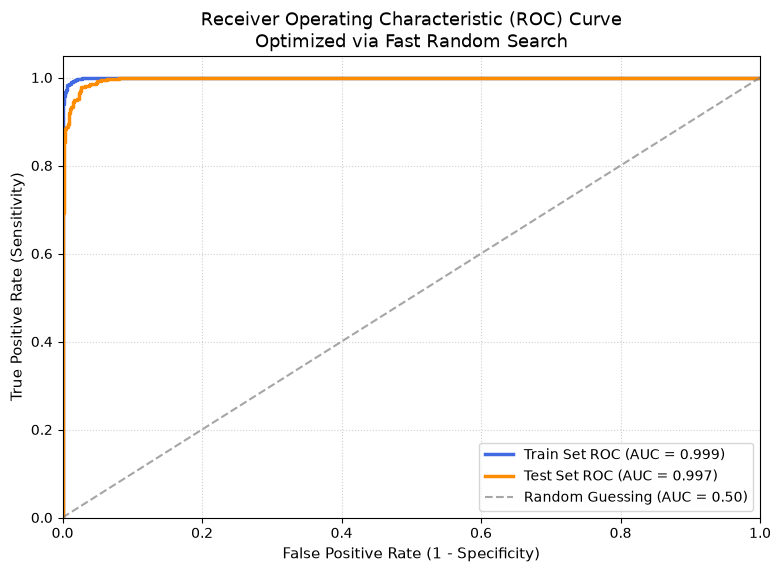

In [80]:
plt.figure(figsize=(9, 6))
plt.plot(fpr_train, tpr_train, color='royalblue', lw=2.5, label=f'Train Set ROC (AUC = {auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2.5, label=f'Test Set ROC (AUC = {auc_test:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.7, label='Random Guessing (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve\nOptimized via Fast Random Search', fontsize=13)
plt.legend(loc="lower right", frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# **XG BOOST**

In [81]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [82]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

xgb_base = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_base.fit(X_train_resampled, y_train_resampled)

y_train_pred_xgb_base = xgb_base.predict(X_train_resampled)
y_test_pred_xgb_base = xgb_base.predict(X_test_scaled)

y_train_prob_xgb_base = xgb_base.predict_proba(X_train_resampled)[:, 1]
y_test_prob_xgb_base = xgb_base.predict_proba(X_test_scaled)[:, 1]

print(f"Base XGBoost Training Accuracy: {accuracy_score(y_train_resampled, y_train_pred_xgb_base):.4f}")
print(f"Base XGBoost Testing Accuracy:  {accuracy_score(y_test, y_test_pred_xgb_base):.4f}")
print(f"Base XGBoost Training ROC AUC:  {roc_auc_score(y_train_resampled, y_train_prob_xgb_base):.4f}")
print(f"Base XGBoost Testing ROC AUC:   {roc_auc_score(y_test, y_test_prob_xgb_base):.4f}")
print("\nClassification Report (Base):\n", classification_report(y_test, y_test_pred_xgb_base))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_xgb_base))

Base XGBoost Training Accuracy: 1.0000
Base XGBoost Testing Accuracy:  0.9892
Base XGBoost Training ROC AUC:  1.0000
Base XGBoost Testing ROC AUC:   0.9978

Classification Report (Base):
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       561
           1       0.99      1.00      0.99      2313

    accuracy                           0.99      2874
   macro avg       0.99      0.98      0.98      2874
weighted avg       0.99      0.99      0.99      2874

Confusion Matrix:
 [[ 539   22]
 [   9 2304]]


In [83]:
from sklearn.metrics import roc_curve, auc
fpr_train, tpr_train, _ = roc_curve(y_train_resampled, y_train_prob_fast)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob_fast)
auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)


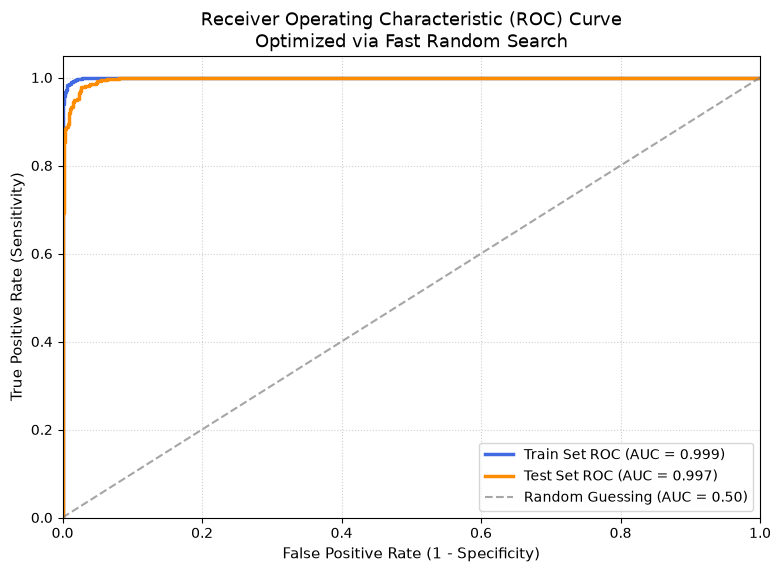

In [84]:
plt.figure(figsize=(9, 6))
plt.plot(fpr_train, tpr_train, color='royalblue', lw=2.5, label=f'Train Set ROC (AUC = {auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2.5, label=f'Test Set ROC (AUC = {auc_test:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.7, label='Random Guessing (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve\nOptimized via Fast Random Search', fontsize=13)
plt.legend(loc="lower right", frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [85]:
#from sklearn.model_selection import RandomizedSearchCV

#xgb_tune = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

#xgb_param_dist = {
    # 'n_estimators': [100, 200, 300],
    # 'learning_rate': [0.01, 0.05, 0.1, 0.2],
    # 'max_depth': [3, 4, 5, 6],
    # 'subsample': [0.6, 0.8, 1.0],
    # 'colsample_bytree': [0.6, 0.8, 1.0],
    # 'gamma': [0, 1, 2, 5]
    #"n_estimators": [200,300,500,700],
    #"gamma": [1,2,3,5],
    #"subsample": [0.6,0.7,0.8],
    #"colsample_bytree": [0.6,0.7,0.8],
    #"reg_alpha": [0,0.1,0.5,1,5],
    #"reg_lambda": [1,5,10,20],
    #"scale_pos_weight": [1,2,3,4]
#}

#xgb_random_search = RandomizedSearchCV(
    #estimator=xgb_tune,
    #param_distributions=xgb_param_dist,
    #n_iter=30,
    #cv=5,
    #scoring='roc_auc',
    #random_state=42,
    #n_jobs=-1
#)

#xgb_random_search.fit(X_train_resampled, y_train_resampled)

#best_xgb = xgb_random_search.best_estimator_

#y_train_pred_xgb_best = best_xgb.predict(X_train_resampled)
#y_test_pred_xgb_best = best_xgb.predict(X_test_scaled)

#y_train_prob_xgb_best = best_xgb.predict_proba(X_train_resampled)[:, 1]
#y_test_prob_xgb_best = best_xgb.predict_proba(X_test_scaled)[:, 1]

#print(f"Best Hyperparameters: {xgb_random_search.best_params_}\n")
#print(f"Tuned XGBoost Training Accuracy: {accuracy_score(y_train_resampled, y_train_pred_xgb_best):.4f}")
#print(f"Tuned XGBoost Testing Accuracy:  {accuracy_score(y_test, y_test_pred_xgb_best):.4f}")
#print(f"Tuned XGBoost Training ROC AUC:  {roc_auc_score(y_train_resampled, y_train_prob_xgb_best):.4f}")
#print(f"Tuned XGBoost Testing ROC AUC:   {roc_auc_score(y_test, y_test_prob_xgb_best):.4f}")
#print("\nClassification Report (Tuned):\n", classification_report(y_test, y_test_pred_xgb_best))

In [86]:
#from sklearn.metrics import roc_curve, auc
#fpr_train, tpr_train, _ = roc_curve(y_train_resampled, y_train_prob_fast)
#fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob_fast)
#auc_train = auc(fpr_train, tpr_train)
#auc_test = auc(fpr_test, tpr_test)


In [87]:
#plt.figure(figsize=(9, 6))
#plt.plot(fpr_train, tpr_train, color='royalblue', lw=2.5, label=f'Train Set ROC (AUC = {auc_train:.3f})')
#plt.plot(fpr_test, tpr_test, color='darkorange', lw=2.5, label=f'Test Set ROC (AUC = {auc_test:.3f})')
#plt.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.7, label='Random Guessing (AUC = 0.50)')
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.05])
#plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
#plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
#plt.title('Receiver Operating Characteristic (ROC) Curve\nOptimized via Fast Random Search', fontsize=13)
#plt.legend(loc="lower right", frameon=True)
#plt.grid(True, linestyle=':', alpha=0.6)
#plt.show()

**HYPERTUNING**

In [88]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

xgb_tune = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

xgb_param_dist = {
    "n_estimators": [50, 80, 100],
    "learning_rate": [0.05, 0.1, 0.15],
    "max_depth": [2, 3, 4],
    "min_child_weight": [2, 5, 8],
    "gamma": [0, 1, 2],
    "subsample": [0.75, 0.85, 0.95],
    "colsample_bytree": [0.75, 0.85, 0.95],
    "reg_alpha": [0.1, 1, 5],
    "reg_lambda": [1, 5, 10],
    "scale_pos_weight": [1]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=xgb_param_dist,
    n_iter=40,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(X_train_resampled, y_train_resampled)

best_xgb = xgb_random_search.best_estimator_

y_train_pred_xgb_best = best_xgb.predict(X_train_resampled)
y_test_pred_xgb_best = best_xgb.predict(X_test_scaled)

y_train_prob_xgb_best = best_xgb.predict_proba(X_train_resampled)[:, 1]
y_test_prob_xgb_best = best_xgb.predict_proba(X_test_scaled)[:, 1]

print(f"Best Hyperparameters: {xgb_random_search.best_params_}\n")
print(f"Tuned XGBoost Training Accuracy: {accuracy_score(y_train_resampled, y_train_pred_xgb_best):.4f}")
print(f"Tuned XGBoost Testing Accuracy:  {accuracy_score(y_test, y_test_pred_xgb_best):.4f}")
print(f"Tuned XGBoost Training ROC AUC:  {roc_auc_score(y_train_resampled, y_train_prob_xgb_best):.4f}")
print(f"Tuned XGBoost Testing ROC AUC:   {roc_auc_score(y_test, y_test_prob_xgb_best):.4f}")
print("\nClassification Report (Tuned):\n", classification_report(y_test, y_test_pred_xgb_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_xgb_best))

Best Hyperparameters: {'subsample': 0.95, 'scale_pos_weight': 1, 'reg_lambda': 10, 'reg_alpha': 5, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.15, 'gamma': 0, 'colsample_bytree': 0.85}

Tuned XGBoost Training Accuracy: 0.9866
Tuned XGBoost Testing Accuracy:  0.9843
Tuned XGBoost Training ROC AUC:  0.9994
Tuned XGBoost Testing ROC AUC:   0.9963

Classification Report (Tuned):
               precision    recall  f1-score   support

           0       0.98      0.94      0.96       561
           1       0.99      1.00      0.99      2313

    accuracy                           0.98      2874
   macro avg       0.98      0.97      0.97      2874
weighted avg       0.98      0.98      0.98      2874

Confusion Matrix:
 [[ 526   35]
 [  10 2303]]


In [89]:
from sklearn.metrics import roc_curve, auc
fpr_train, tpr_train, _ = roc_curve(y_train_resampled, y_train_prob_fast)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob_fast)
auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)


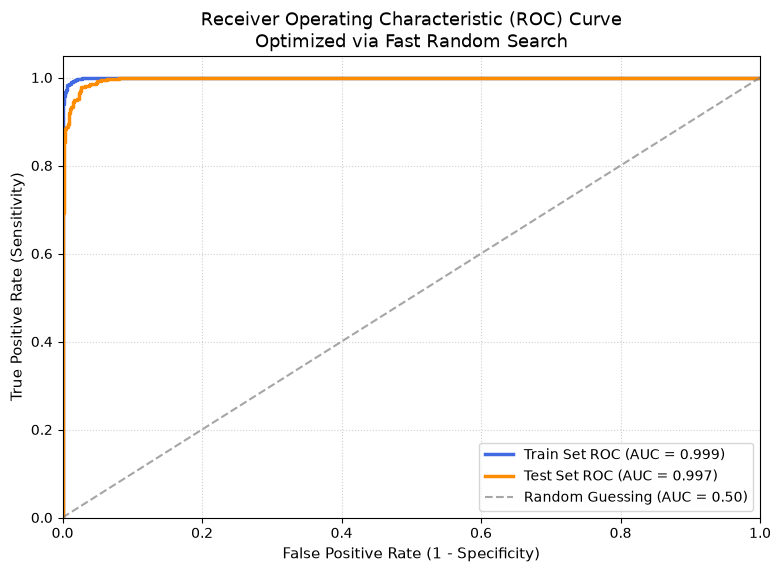

In [90]:
plt.figure(figsize=(9, 6))
plt.plot(fpr_train, tpr_train, color='royalblue', lw=2.5, label=f'Train Set ROC (AUC = {auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2.5, label=f'Test Set ROC (AUC = {auc_test:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.7, label='Random Guessing (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve\nOptimized via Fast Random Search', fontsize=13)
plt.legend(loc="lower right", frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# **NEW TRIALS**

In [91]:
df1.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,2,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,2,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,2,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [92]:
df1.tail()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
9573,0,0,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1
9574,0,0,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1
9575,0,2,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1
9576,0,4,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1
9577,0,2,0.1392,853.43,11.264464,16.28,732,4740.000000,37879,57.0,6,0,0,1


**XGBOOST**

In [93]:
input_data=np.array([[2, 0.1471, 354.76, 12.180755, 9.39, 672, 10474.0, 215372, 82.1, 2, 2, 0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled)

array([0])

In [94]:
input_data=np.array([[2,0.1392,853.43,12.264464,16.28,732,4740.000000,37880,57.0,6,0,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([0])

In [95]:
input_data=np.array([[1,0.1426,108.92,11.300732,14.97,667,4066.000000,4740,39.5,0,1,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([1])

In [96]:
input_data=np.array([[4,0.1600,351.58,10.819778,19.18,692,1800.000000,0,4.2,5,0,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([0])

In [97]:
input_data=np.array([[1,0.1081,328.22,11.082143,14.29,707,2760.000000,33623,76.7,2,0,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([1])

In [98]:
input_data=np.array([[2,0.0863,219.54,8.487972,9.73,727,1559.958333,7282,44.6,0,0,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([1])

In [99]:
input_data=np.array([[6,0.0714,92.82,12.512925,6.50,747,4384.000000,4021,5.8,0,1,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([1])

In [100]:
input_data=np.array([[1,0.1114,131.22,11.002100,11.08,722,5116.000000,34220,78.6,0,0,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([1])

In [101]:
input_data=np.array([[2,0.1099,560.50,12.235243,17.84,727,6840.041667,18753,29.0,4,0,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([0])

In [102]:
input_data=np.array([[0,0.1385,511.56,12.323856,12.33,687,6420.041667,485489,51.2,4,0,0]])
input_scaled=scaler.transform(input_data)
best_xgb.predict(input_scaled) #correct

array([0])

**XGB: 9/10**

In [103]:
new_data=pd.read_csv(r'C:\Users\ruthw\Downloads\unseen_loan_data_100_samples.csv')

In [104]:
new_data.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.138745,325.050802,11.413791,5.306731,677,4392.205738,17255,70.968762,1,0,0,0
1,1,debt_consolidation,0.115762,255.970987,11.028060,18.903228,687,4597.056437,17160,92.186691,1,0,0,0
2,1,debt_consolidation,0.143204,718.216839,11.020300,19.028397,693,5406.063571,19311,34.002746,0,0,0,0
3,1,debt_consolidation,0.143358,810.771549,11.078515,24.812153,702,10297.408934,30167,84.350425,1,0,0,0
4,1,debt_consolidation,0.134129,164.050237,10.384467,10.697335,678,4967.975004,0,45.613235,2,1,0,0


In [105]:
newdataX=new_data.drop(columns=['credit.policy', 'not.fully.paid'])
newdataX

,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec
0,debt_consolidation,0.138745,325.050802,11.413791,5.306731,677,4392.205738,17255,70.968762,1,0,0
1,debt_consolidation,0.115762,255.970987,11.028060,18.903228,687,4597.056437,17160,92.186691,1,0,0
2,debt_consolidation,0.143204,718.216839,11.020300,19.028397,693,5406.063571,19311,34.002746,0,0,0
3,debt_consolidation,0.143358,810.771549,11.078515,24.812153,702,10297.408934,30167,84.350425,1,0,0
4,debt_consolidation,0.134129,164.050237,10.384467,10.697335,678,4967.975004,0,45.613235,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
95,all_other,0.120634,101.001831,10.415577,19.868549,698,4588.310181,776,71.193211,2,0,1
96,debt_consolidation,0.114735,433.176435,10.973658,9.586982,720,4281.003809,9824,60.466691,1,0,0
97,all_other,0.134897,323.648658,10.995240,13.247337,677,4110.870265,8188,47.921983,1,0,0
98,debt_consolidation,0.135822,169.768182,11.002488,4.989468,650,6318.102225,2414,20.692922,3,1,0


In [106]:
newdataY=(['credit.policy'])

In [107]:
newdataX_enc = newdataX.copy()
newdataX_enc['purpose'] = le['purpose'].transform(newdataX_enc['purpose'])

newdataX_scaled = scaler.transform(newdataX_enc)

newdatapred = best_xgb.predict(newdataX_scaled)
newdataY = new_data['credit.policy']
print('Accuracy: ', accuracy_score(newdataY, newdatapred))

Accuracy:  0.98


**RANDOM FOREST**

In [108]:
input_data=np.array([[0, 0, 0.1471, 354.76, 12.180755, 10.39, 672, 10474.0, 215372, 82.1, 2, 0, ]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled)

array([0])

In [109]:
input_data=np.array([[2,0.1392,853.43,12.264464,16.28,732,4740.000000,37880,57.0,6,0,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([0])

In [110]:
input_data=np.array([[1,0.1426,108.92,11.300732,14.97,667,4066.000000,4740,39.5,0,1,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([1])

In [111]:
input_data=np.array([[4,0.1600,351.58,10.819778,19.18,692,1800.000000,0,4.2,5,0,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([0])

In [112]:
input_data=np.array([[1,0.1081,328.22,11.082143,14.29,707,2760.000000,33623,76.7,2,0,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([1])

In [113]:
df1.head(15)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,2,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,2,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,2,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0
5,1,1,0.0788,125.13,11.904968,16.98,727,6120.041667,50807,51.0,0,0,0,0
6,1,2,0.1496,194.02,10.714418,4.00,667,3180.041667,3839,76.8,0,0,1,1
7,1,0,0.1114,131.22,11.002100,11.08,722,5116.000000,24220,68.6,0,0,0,1
8,1,4,0.1134,87.19,11.407565,17.25,682,3989.000000,69909,51.1,1,0,0,0
9,1,2,0.1221,84.12,10.203592,10.00,707,2730.041667,5630,23.0,1,0,0,0


In [114]:
input_data=np.array([[2,0.0863,219.54,8.487972,9.73,727,1559.958333,7282,44.6,0,0,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([1])

In [115]:
input_data=np.array([[6,0.0714,92.82,12.512925,6.50,747,4384.000000,4021,5.8,0,1,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([1])

In [116]:
input_data=np.array([[0,0.1114,131.22,11.002100,11.08,722,5116.000000,34220,78.6,0,0,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([1])

In [117]:
df1.tail(15)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
9563,0,2,0.1099,556.50,11.225243,17.84,727,6840.041667,18753,29.0,4,0,0,1
9564,0,0,0.1385,511.56,12.323856,12.33,687,6420.041667,385489,51.2,4,0,0,0
9565,0,0,0.1459,396.35,10.308953,21.04,697,3390.000000,26117,78.4,6,0,0,1
9566,0,0,0.2164,551.08,11.002100,24.06,662,1800.000000,16441,49.8,9,0,0,1
9567,0,0,0.1311,101.24,10.968198,8.23,687,2790.041667,1514,13.8,5,0,0,0
9568,0,0,0.1979,37.06,10.645425,22.17,667,5916.000000,28854,59.8,6,0,1,0
9569,0,4,0.1426,823.34,12.429216,3.62,722,3239.958333,33575,83.9,5,0,0,1
9570,0,0,0.1671,113.63,10.645425,28.06,672,3210.041667,25759,63.8,5,0,0,1
9571,0,0,0.1568,161.01,11.225243,8.00,677,7230.000000,6909,29.2,4,0,1,1
9572,0,2,0.1565,69.98,10.110472,7.02,662,8190.041667,2999,39.5,6,0,0,1


In [118]:
input_data=np.array([[2,0.1099,560.50,12.235243,17.84,727,6840.041667,18753,29.0,4,0,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled)

array([0])

In [119]:
input_data=np.array([[0,0.1385,511.56,12.323856,12.33,687,6420.041667,485489,51.2,4,0,0]])
input_scaled=scaler.transform(input_data)
best_rf_rs.predict(input_scaled) #correct

array([0])

**Random forest: 9/10**

# **MODEL COMPARISION**

In [120]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": best_log_reg,
    "Decision Tree": best_dt,
    "Random Forest": best_rf_rs,
    "XGBoost": best_xgb,
}

rows = []

for name, model in models.items():
    tr_pred = model.predict(X_train_resampled)
    te_pred = model.predict(X_test_scaled)

    tr_prob = model.predict_proba(X_train_resampled)[:, 1]
    te_prob = model.predict_proba(X_test_scaled)[:, 1]

    rows.append([
        name,
        accuracy_score(y_train_resampled, tr_pred),
        accuracy_score(y_test, te_pred),
        roc_auc_score(y_train_resampled, tr_prob),
        roc_auc_score(y_test, te_prob),
        precision_score(y_test, te_pred),
        recall_score(y_test, te_pred),
        f1_score(y_test, te_pred),
    ])

result = pd.DataFrame(
    rows,
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy",
        "Train ROC AUC",
        "Test ROC AUC",
        "Precision",
        "Recall",
        "F1 Score",
    ],
)

result = result.sort_values("Test ROC AUC", ascending=False).reset_index(drop=True)
result

,Model,Train Accuracy,Test Accuracy,Train ROC AUC,Test ROC AUC,Precision,Recall,F1 Score
0,Random Forest,0.985362,0.983994,0.999486,0.996869,0.987108,0.993083,0.990086
1,XGBoost,0.986567,0.984342,0.999424,0.996337,0.985030,0.995677,0.990325
2,Decision Tree,0.986011,0.988170,0.992962,0.982981,0.990108,0.995244,0.992669
3,Logistic Regression,0.851028,0.856994,0.930379,0.934170,0.960310,0.857760,0.906143


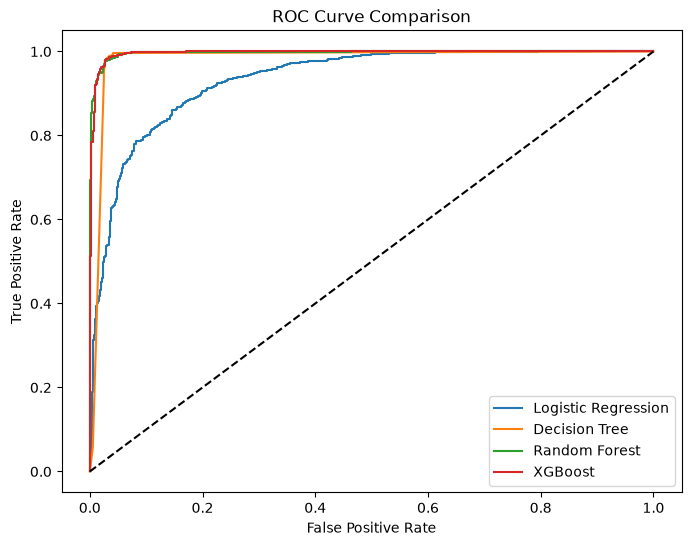

In [121]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, model in models.items():
    prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# **CROSS VALIDATION**

In [122]:
from sklearn.model_selection import cross_val_score

cv=cross_val_score(
    model,
    X_train_resampled,
    y_train_resampled,
    cv=5,
    scoring="roc_auc"
)

print(cv)
print("Mean ROC AUC :",cv.mean())

[0.99643017 0.99922682 0.99854289 0.99686695 0.99873909]
Mean ROC AUC : 0.9979611848215084


In [123]:
from sklearn.metrics import classification_report
pred=model.predict(X_test_scaled)
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96       561
           1       0.99      1.00      0.99      2313

    accuracy                           0.98      2874
   macro avg       0.98      0.97      0.97      2874
weighted avg       0.98      0.98      0.98      2874



In [125]:
import pickle

with open('model.pkl', 'wb') as file:
    pickle.dump(best_xgb, file)